In [192]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import os

In [193]:
# Put all the mat files in a list for easy access
dataFiles = ["./AboveInlet.mat", "./BelowStep.mat", "./AboveStep.mat", "./BelowNozzle.mat"]

# All other necessary data will be in dictionaries indexed by data file
locNames = {}
for df in dataFiles:
    locNames[df] = os.path.splitext(os.path.basename(df))[0]

mat = {}
piv = {}
for df in dataFiles:
    mat[df] = scipy.io.loadmat(df)
    piv[df] = mat[df].get(locNames[df])



In [194]:
# To start, just work with zero degree plane
piv_zerodeg = {}
for df in dataFiles:
    piv_zerodeg[df] = piv[df]['zerodeg']


In [195]:
# Extract velocity and coordinates for each mat file
# TODO: Understand this wacky structure---for instance, why [0][0]['vx'][0][0] ???
vx = {}
vy = {}
vz = {}

x = {}
y = {}

for df in dataFiles:

    # x-vel (horizontal velocity)
    vx[df] = piv_zerodeg[df][0][0]['vx'][0][0]

    nx = vx[df].shape[0]
    ny = vx[df].shape[1]

    # y-vel
    vy[df] = piv_zerodeg[df][0][0]['vy'][0][0]
    assert vy[df].shape[0] == nx, "what? size inconsistency"
    assert vy[df].shape[1] == ny, "what? size inconsistency"

    # z-vel
    vz[df] = piv_zerodeg[df][0][0]['vz'][0][0]
    assert vz[df].shape[0] == nx, "what? size inconsistency"
    assert vz[df].shape[1] == ny, "what? size inconsistency"

    # coordinates
    x[df] = piv[df]['x'][0][0].reshape((nx,))
    y[df] = piv[df]['y'][0][0].reshape((ny,))

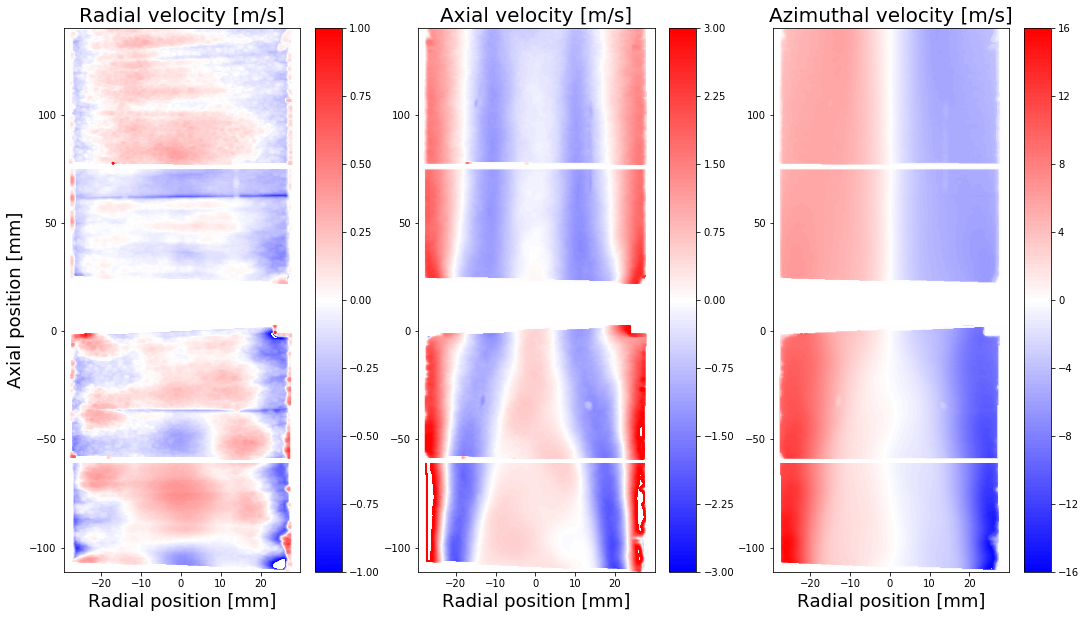

In [196]:
xmin = -1
xmax =  1
xlev = np.linspace(xmin,xmax,128)
xtic = np.linspace(xmin,xmax,9)

ymin = -3
ymax =  3
ylev = np.linspace(ymin,ymax,128)
ytic = np.linspace(ymin,ymax,9)

zmin = -16
zmax =  16
zlev = np.linspace(zmin,zmax,128)
ztic = np.linspace(zmin,zmax,9)

fig, ax = plt.subplots(1,3,figsize=(18,10))

# x-velocity
for df in dataFiles:
    cnt = ax[0].contourf(x[df],y[df],vx[df].transpose(),levels=xlev,cmap='bwr')
    for c in cnt.collections:
        c.set_edgecolor("face")

cbar = plt.colorbar(cnt, ax=ax[0])
cbar.set_ticks(xtic)
#cbar.set_label(r"$v_x$ [m/s]", fontsize=18)

ax[0].set_ylabel('Axial position [mm]', fontsize=18)
ax[0].set_xlabel('Radial position [mm]', fontsize=18)
ax[0].set_title('Radial velocity [m/s]', fontsize=20)

# y-velocity
for df in dataFiles:
    cnt = ax[1].contourf(x[df],y[df],vy[df].transpose(),levels=ylev,cmap='bwr')
    for c in cnt.collections:
        c.set_edgecolor("face")

cbar = plt.colorbar(cnt, ax=ax[1])
cbar.set_ticks(ytic)
#cbar.set_label(r"$v_y$ [m/s]", fontsize=18)

ax[1].set_xlabel('Radial position [mm]', fontsize=18)
ax[1].set_title('Axial velocity [m/s]', fontsize=20)
    
# z-velocity
for df in dataFiles:
    cnt = ax[2].contourf(x[df],y[df],vz[df].transpose(),levels=zlev,cmap='bwr')
    for c in cnt.collections:
        c.set_edgecolor("face")

cbar = plt.colorbar(cnt, ax=ax[2])
cbar.set_ticks(ztic)
#cbar.set_label(r"$v_z$ [m/s]", fontsize=18)

ax[2].set_xlabel('Radial position [mm]', fontsize=18)
ax[2].set_title('Azimuthal velocity [m/s]', fontsize=20)

plt.savefig('zerodeg.png',density=300)
plt.show()